# **DATASET: Pittsburgh Parks**

**Description:** A list of city parks and which neighbord they reside in <br>
**Metric:** Greater number of parks = better neighborhood. More parks in a neighborhood allow people to get fresh air, exercise, and enjoy extracurricular activities (i.e. sports). This contributes to healthy residents both physically and mentally.

In [3]:
import pandas as pd

In [4]:
parksData = pd.read_csv('https://data.wprdc.org/datastore/dump/fa329e3d-89ff-4708-8ddf-81bfedcad11d')
pd.set_option('display.max_rows', 30)

In [92]:
parksData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   _id                         209 non-null    int64  
 1   id                          209 non-null    int64  
 2   name                        209 non-null    object 
 3   type                        209 non-null    object 
 4   maintenance_responsibility  209 non-null    object 
 5   image                       63 non-null     object 
 6   neighborhood                209 non-null    object 
 7   council_district            209 non-null    int64  
 8   ward                        209 non-null    int64  
 9   tract                       209 non-null    int64  
 10  public_works_division       209 non-null    int64  
 11  pli_division                209 non-null    int64  
 12  police_zone                 209 non-null    int64  
 13  fire_zone                   209 non

In [93]:
parksData.columns

Index(['_id', 'id', 'name', 'type', 'maintenance_responsibility', 'image',
       'neighborhood', 'council_district', 'ward', 'tract',
       'public_works_division', 'pli_division', 'police_zone', 'fire_zone',
       'latitude', 'longitude'],
      dtype='object')

In [94]:
parksData

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
0,1,2111959181,Able Long Park,Park,Parks - Southern,https://tools.wprdc.org/images/pittsburgh/park...,Beechview,4,19,42003192000,5,19,6,4-28,40.408118,-80.028197
1,2,1109513049,Albert Turk Graham Park,Park,Parks - Schenley,https://tools.wprdc.org/images/pittsburgh/park...,Crawford-Roberts,6,3,42003030500,3,3,2,2-1,40.440507,-79.984018
2,3,1544096765,Alcoa Park,Park,Parks - Northern,NaN,North Shore,1,22,42003563200,6,22,1,1-20,40.447481,-80.001017
3,4,1212681573,Allegheny Commons,Park,Parks - Northern,NaN,Allegheny Center,1,22,42003562700,1,22,1,1-7,40.453126,-80.009158
4,5,954863286,Allegheny Landing Park,Park,Parks - Northern,NaN,North Shore,1,22,42003563200,6,22,1,1-20,40.447184,-80.002907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,205,1460363095,Woods Run Park,Park,Parks - Northern,https://tools.wprdc.org/images/pittsburgh/park...,Marshall-Shadeland,1,27,42003271500,1,27,1,1-14,40.476383,-80.029253
205,206,930068146,Young Field Park,Park,Parks - Northern,NaN,Marshall-Shadeland,1,27,42003271500,1,27,1,1-14,40.472963,-80.032768
206,207,1127012019,Zulema Park,Park,Parks - Schenley,NaN,Central Oakland,3,4,42003040500,3,4,4,2-14,40.435693,-79.957048
207,208,1719897212,Liberty Green Park,Park,Parks - Northeast,NaN,East Liberty,9,11,42003111500,2,11,5,3-10,40.462773,-79.919314


## **Columns to Remove**

In [6]:
parksData['type'].unique()

array(['Park', 'Traffic Island/Median', 'Building Grounds',
       'Monument/Memorial', 'Open Space'], dtype=object)

In [19]:
removeColumns = ['_id', 'id', 'maintenance_responsibility', 'image', 'council_district', 'ward', 'tract', 'public_works_division', 'pli_division', 'police_zone', 'fire_zone', 'latitude', 'longitude']
parksData.drop(columns = removeColumns, inplace = True)

## **Count of Parks, Traffic Island/Medians, Building Grounds, Monument/Memorials, and Open Space Within Each Neighborhood.**

In [95]:
(parksData
    .assign(total = parksData.groupby('neighborhood')['type'].transform('count'),
            count = parksData.groupby(['neighborhood', 'type'])['type'].transform('count'))   
    .drop_duplicates(subset = ['type', 'neighborhood'])
    .sort_values(by = ['total', 'neighborhood', 'count'], ascending = (False, True, False))
    .set_index(['neighborhood', 'type'])
    [['name', 'count', 'total']]
)

name  \
neighborhood              type                                               
East Liberty              Traffic Island/Median             Amber Triangle   
                          Park                           East Liberty Park   
Central Business District Traffic Island/Median              Bedford Strip   
                          Park                   Allegheny Riverfront Park   
                          Open Space                    Market Square Park   
...                                                                    ...   
Squirrel Hill North       Park                               Wightman Park   
Stanton Heights           Park                                  Dinan Park   
Upper Hill                Park                     Robert E. Williams Park   
West Oakland              Park                    Shalane's Play Yard Park   
Windgap                   Park                              Chartiers Park   

                                                 count  total  
neighborhood              type                                 
East Liberty              Traffic Island/Median      8     12  
                          Park                       4     12  
Central Business District Traffic Island/Median      5     10  
                          Park                       3     10  
                          Open Space                 2     10  
...                                                ...    ...  
Squirrel Hill North       Park                       1      1  
Stanton Heights           Park                       1      1  
Upper Hill                Park                       1      1  
West Oakland              Park                       1      1  
Windgap                   Park                       1      1  

[104 rows x 3 columns]

## **Remove Non-Park Types**

In [96]:
parksData.query('type == "Open Space"')

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
57,58,1061718486,Emerald View Park - Duquesne Heights Greenway,Open Space,Parks - Western,NaN,Duquesne Heights,2,19,42003191100,5,19,3,4-1,40.433300,-80.023642
113,114,1119177163,Loraine St Park,Open Space,1st Division,NaN,Central Northside,6,25,42003220600,1,25,1,1-6,40.458716,-80.006494
117,118,543596199,Market Square Park,Open Space,Parks - Northern,NaN,Central Business District,6,1,42003020100,6,1,2,1-4,40.440689,-80.002564
129,130,383659775,Mellon Square Park,Open Space,Parks - Northern,https://tools.wprdc.org/images/pittsburgh/park...,Central Business District,6,2,42003020100,6,2,2,1-4,40.440958,-79.997460
162,163,985054965,Saline Street Green Space,Open Space,3rd Division,NaN,Greenfield,5,14,42003980500,3,14,4,2-12,40.429529,-79.939700
208,241,1305573349,Esser Plaza Park,Open Space,Parks - Southern,NaN,South Side Flats,3,17,42003170200,3,17,3,4-24,40.428564,-79.986239


The reason I am removing every type but the parks is because oftentimes the other types (e.g. monument, memorials, traffic island, medians, open space, and building grounds) are not good representations of parks.
* Traffic islands/medians are not resembalance of parks
* Monuments are not resembalance of parks
* Building grounds often included buildings such as nursing homes or other activity centers
* Open spaces often included plazas (no grass), small get-together spots, etc. Not close enough to the 'parks' type

## **Count and Name of Parks**

In [97]:
(parksData
    .query('type == "Park"')  
    .assign(count = lambda df: df.groupby('neighborhood')['type'].transform('count'))
    .set_index(['neighborhood', 'name'])
    .sort_values(by = ['count', 'neighborhood', 'name'], ascending = (False, True, True))
    [['type', 'count']]
)

type  count
neighborhood   name                                                    
Beechview      Able Long Park                               Park      6
               Alton Park                                   Park      6
               Beechview Healthy Active Living Center Park  Park      6
               Pauline Park                                 Park      6
               Tropical Park                                Park      6
...                                                          ...    ...
Swisshelm Park Swisshelm Park                               Park      1
Upper Hill     Robert E. Williams Park                      Park      1
West End       Wabash Park                                  Park      1
West Oakland   Shalane's Play Yard Park                     Park      1
Windgap        Chartiers Park                               Park      1

[153 rows x 2 columns]

## **Manipulate DataFrame to Account for North, East, South, West Neighborhoods** 

In [98]:
parksData['neighborhood'].drop_duplicates().sort_values()

3         Allegheny Center
55               Allentown
45               Arlington
15              Banksville
9        Bedford Dwellings
              ...         
48     Upper Lawrenceville
190               West End
165           West Oakland
39                Westwood
35                 Windgap
Name: neighborhood, Length: 73, dtype: object

#### **Duplicate Neighborhoods (Have North, Sout, East, West)**
* Homewood
* Perry
* Point Breeze
* Oakland
* South Side
* Squirrel Hill

#### **Change Neighborhood Names** 

In [20]:
parksFinal = parksData

# Change to use replace function

In [100]:
# Homewood
parksFinal[parksFinal['neighborhood'].str.contains('Homewood')]

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
19,20,445268632,Baxter Park,Park,Parks - Eastern,NaN,Homewood North,9,13,42003130200,2,13,5,3-17,40.456082,-79.889197
42,43,1026385297,Dallas Park,Park,Parks - Eastern,NaN,Homewood West,9,12,42003120700,2,12,5,3-17,40.457873,-79.904512
94,95,1212017187,Homewood Park,Park,Parks - Eastern,NaN,Homewood South,9,13,42003130300,2,13,5,3-17,40.453906,-79.899810
95,96,2071655328,Homewood Healthy Active Living Center,Building Grounds,Parks - Eastern,NaN,Homewood North,9,13,42003130200,2,13,5,3-17,40.456886,-79.892961


In [21]:
parksFinal.loc[19, 'neighborhood'] = 'Homewood'
parksFinal.loc[42, 'neighborhood'] = 'Homewood'
parksFinal.loc[94, 'neighborhood'] = 'Homewood'
parksFinal.loc[95, 'neighborhood'] = 'Homewood'

In [67]:
# Perry
parksFinal[parksFinal['neighborhood'].str.contains('Perry')]

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
40,41,1049783368,Cross and Strauss Park,Park,Parks - Northern,https://tools.wprdc.org/images/pittsburgh/park...,Perry South,6,26,42003261400,1,26,1,1-12,40.465073,-80.020064
73,74,1057506371,Fowler Park,Park,Parks - Northern,NaN,Perry South,6,26,42003261400,1,26,1,1-23,40.470202,-80.009940
81,82,1261580004,Garvin Park,Park,Parks - Northern,NaN,Perry North,1,26,42003260200,1,26,1,1-15,40.492550,-80.018539
157,158,536526140,Riverview Park,Park,Parks - Northern,https://tools.wprdc.org/images/pittsburgh/park...,Perry North,1,26,42003980400,1,26,1,1-15,40.482911,-80.019596


In [22]:
parksFinal.loc[40, 'neighborhood'] = 'Perry'
parksFinal.loc[73, 'neighborhood'] = 'Perry'
parksFinal.loc[81, 'neighborhood'] = 'Perry'
parksFinal.loc[157, 'neighborhood'] = 'Perry'

In [69]:
# Point Breeze
parksFinal[parksFinal['neighborhood'].str.contains('Point Breeze')]

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
53,54,1828459271,Edgerton Circle,Traffic Island/Median,3rd Division,NaN,Point Breeze,8,14,42003140400,3,14,4,2-17,40.447884,-79.913167
83,84,1957191796,Glen Arden Circle,Traffic Island/Median,3rd Division,NaN,Point Breeze,8,14,42003140400,3,14,4,2-17,40.447140,-79.913128
84,85,818763075,Glen Arden Triangle,Traffic Island/Median,3rd Division,NaN,Point Breeze,8,14,42003140400,3,14,4,2-17,40.448256,-79.911870
103,104,1976961035,Le Roi Rd Island,Traffic Island/Median,3rd Division,https://tools.wprdc.org/images/pittsburgh/park...,Point Breeze,9,14,42003140600,3,14,4,3-14,40.447663,-79.904074
126,127,373591278,McPherson Blvd Strip,Traffic Island/Median,Parks - Eastern,https://tools.wprdc.org/images/pittsburgh/park...,Point Breeze North,9,14,42003140500,2,14,4,3-14,40.454939,-79.908451
127,128,1565122603,Mellon Park,Park,Parks - Eastern,NaN,Point Breeze,8,14,42003140400,3,14,4,2-17,40.453355,-79.916868
128,129,1113107138,Mellon Park Island,Traffic Island/Median,3rd Division,NaN,Point Breeze,8,14,42003140400,3,14,4,2-17,40.452374,-79.915329
156,157,1043382575,Reynolds St Planting Circle,Traffic Island/Median,3rd Division,https://tools.wprdc.org/images/pittsburgh/park...,Point Breeze,9,14,42003140600,3,14,4,3-14,40.446447,-79.903252
178,179,1446434219,Thomas Blvd Planting Strip,Traffic Island/Median,Parks - Eastern,https://tools.wprdc.org/images/pittsburgh/park...,Point Breeze North,9,14,42003140500,2,14,4,3-14,40.454059,-79.909141
198,199,2031115592,Westinghouse Park,Park,Parks - Eastern,NaN,Point Breeze North,9,14,42003140500,2,14,4,3-14,40.453006,-79.902758


In [23]:
parksFinal.loc[53, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[83, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[84, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[103, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[126, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[127, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[128, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[156, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[178, 'neighborhood'] = 'Point Breeze'
parksFinal.loc[198, 'neighborhood'] = 'Point Breeze'

In [70]:
# Oakland
parksFinal[parksFinal['neighborhood'].str.contains('Oakland')]

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
17,18,2014605692,Bates St Triangle,Traffic Island/Median,3rd Division,https://tools.wprdc.org/images/pittsburgh/park...,South Oakland,3,4,42003040900,3,4,4,2-11,40.434821,-79.956270
25,26,79129285,Boundary Street Park,Park,Parks - Schenley,NaN,Central Oakland,3,4,42003040600,3,4,4,2-11,40.438528,-79.950589
38,39,149758095,Craft Triangle,Traffic Island/Median,3rd Division,NaN,South Oakland,6,4,42003040900,3,4,4,2-14,40.435961,-79.961899
76,77,984641225,Frazier Park,Park,Parks - Schenley,https://tools.wprdc.org/images/pittsburgh/park...,South Oakland,3,4,42003040900,3,4,4,2-11,40.429303,-79.954803
87,88,1264215460,Harris Triangle,Traffic Island/Median,3rd Division,NaN,North Oakland,6,5,42003562000,3,5,4,2-23,40.456040,-79.954771
102,103,1902802741,Lawn and Ophelia Park,Park,Parks - Schenley,NaN,South Oakland,6,4,42003040900,3,4,4,2-10,40.435434,-79.965262
141,142,1185452095,Niagara Park,Park,Parks - Schenley,https://tools.wprdc.org/images/pittsburgh/park...,South Oakland,3,4,42003040900,3,4,4,2-10,40.434712,-79.960137
143,144,55889045,Oakland Square,Traffic Island/Median,3rd Division,https://tools.wprdc.org/images/pittsburgh/park...,Central Oakland,3,4,42003040600,3,4,4,2-11,40.437099,-79.951629
148,149,794761479,Parkview Islands,Traffic Island/Median,3rd Division,https://tools.wprdc.org/images/pittsburgh/park...,Central Oakland,3,4,42003040600,3,4,4,2-11,40.435518,-79.951916
165,166,90818564,Shalane's Play Yard Park,Park,Parks - Schenley,NaN,West Oakland,6,4,42003040200,3,4,4,2-10,40.442554,-79.964885


In [24]:
parksFinal.loc[17, 'neighborhood'] = 'Oakland'
parksFinal.loc[25, 'neighborhood'] = 'Oakland'
parksFinal.loc[38, 'neighborhood'] = 'Oakland'
parksFinal.loc[76, 'neighborhood'] = 'Oakland'
parksFinal.loc[87, 'neighborhood'] = 'Oakland'
parksFinal.loc[102, 'neighborhood'] = 'Oakland'
parksFinal.loc[141, 'neighborhood'] = 'Oakland'
parksFinal.loc[143, 'neighborhood'] = 'Oakland'
parksFinal.loc[148, 'neighborhood'] = 'Oakland'
parksFinal.loc[165, 'neighborhood'] = 'Oakland'
parksFinal.loc[206, 'neighborhood'] = 'Oakland'

In [34]:
# Squirrel Hill
parksFinal[parksFinal['neighborhood'].str.contains('Squirrel Hill')]

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
43,44,564546832,Davis Park,Park,Parks - Eastern,NaN,Squirrel Hill South,5,14,42003141300,3,14,4,2-21,40.432365,-79.924957
77,78,1948519895,Frick Park,Park,Parks - Eastern,https://tools.wprdc.org/images/pittsburgh/park...,Squirrel Hill South,5,14,42003980300,3,14,4,2-20,40.428102,-79.906524
130,131,1940766525,Monitor St and St Phil Islands,Traffic Island/Median,3rd Division,https://tools.wprdc.org/images/pittsburgh/park...,Squirrel Hill South,5,14,42003141400,3,14,4,2-21,40.426472,-79.919144
161,162,1407327460,Saline St Passive Area,Traffic Island/Median,3rd Division,NaN,Squirrel Hill South,5,15,42003151700,3,15,4,2-12,40.419390,-79.926402
163,164,1881425039,Schenley Park,Park,Parks - Schenley,NaN,Squirrel Hill South,5,14,42003980500,3,14,4,2-8,40.435544,-79.942978
187,188,1068803176,Vietnam Island,Monument/Memorial,3rd Division,https://tools.wprdc.org/images/pittsburgh/park...,Squirrel Hill South,5,14,42003140800,3,14,4,2-21,40.437918,-79.912627
201,202,420525223,Wightman Park,Park,Parks - Eastern,NaN,Squirrel Hill North,8,14,42003140300,3,14,4,2-18,40.443330,-79.927066


In [25]:
parksFinal.loc[43, 'neighborhood'] = 'Squirrel Hill'
parksFinal.loc[77, 'neighborhood'] = 'Squirrel Hill'
parksFinal.loc[130, 'neighborhood'] = 'Squirrel Hill'
parksFinal.loc[161, 'neighborhood'] = 'Squirrel Hill'
parksFinal.loc[163, 'neighborhood'] = 'Squirrel Hill'
parksFinal.loc[187, 'neighborhood'] = 'Squirrel Hill'
parksFinal.loc[201, 'neighborhood'] = 'Squirrel Hill'

In [155]:
# South Side
parksFinal[parksFinal['neighborhood'].str.contains('South Side')]

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
10,11,1928748922,Arlington Park,Park,Parks - Southern,NaN,South Side,3,16,42003160800,3,16,3,4-22,40.418283,-79.975050
11,12,1334547409,Arlington Gym,Building Grounds,Parks - Southern,NaN,South Side,3,16,42003160800,3,16,3,4-22,40.419241,-79.975076
12,13,1848662473,Armstrong Park,Park,Parks - Southern,NaN,South Side,3,17,42003170200,3,17,3,4-24,40.428056,-79.985842
36,37,712782057,Cobden Street Park,Park,Parks - Southern,NaN,South Side,3,16,42003160800,3,16,3,4-22,40.419338,-79.968198
54,55,303472511,Eleanor Street Park,Park,Parks - Southern,NaN,South Side,3,16,42003160800,3,16,3,4-22,40.421408,-79.972879
131,132,375307767,Monongahela Park,Park,Parks - Southern,NaN,South Side,3,16,42003160800,3,16,3,4-22,40.421699,-79.966333
145,146,581560925,Oliver Bath House,Building Grounds,Parks - Southern,NaN,South Side,3,17,42003170200,3,17,3,4-2,40.429576,-79.988870
146,147,583639890,Ormsby Park,Park,Parks - Southern,NaN,South Side,3,16,42003160900,3,16,3,4-24,40.429264,-79.974139
169,170,63657321,Southside Market House,Building Grounds,Parks - Southern,NaN,South Side,3,17,42003170200,3,17,3,4-24,40.429433,-79.986445
170,171,353743875,Southside Park,Park,Parks - Southern,NaN,South Side,3,17,42003160800,3,17,3,4-22,40.420951,-79.977412


In [26]:
parksFinal.loc[10, 'neighborhood'] = 'South Side'
parksFinal.loc[11, 'neighborhood'] = 'South Side'
parksFinal.loc[12, 'neighborhood'] = 'South Side'
parksFinal.loc[36, 'neighborhood'] = 'South Side'
parksFinal.loc[54, 'neighborhood'] = 'South Side'
parksFinal.loc[131, 'neighborhood'] = 'South Side'
parksFinal.loc[145, 'neighborhood'] = 'South Side'
parksFinal.loc[146, 'neighborhood'] = 'South Side'
parksFinal.loc[169, 'neighborhood'] = 'South Side'
parksFinal.loc[170, 'neighborhood'] = 'South Side'
parksFinal.loc[171, 'neighborhood'] = 'South Side'
parksFinal.loc[203, 'neighborhood'] = 'South Side'
parksFinal.loc[208, 'neighborhood'] = 'South Side'

## **Final Parks DataFrame**

In [27]:
parksFinal =( parksFinal
            .query('type == "Park"')  
            .assign(count = lambda df: df.groupby('neighborhood')['type'].transform('count'))
            .set_index(['neighborhood', 'name'])
            .sort_values(by = ['count', 'neighborhood', 'name'], ascending = (False, True, True))
            [['type', 'count']]
            )
parksFinal.head(50)

type  count
neighborhood       name                               
South Side         Arlington Park          Park      9
                   Armstrong Park          Park      9
                   Cobden Street Park      Park      9
                   Eleanor Street Park     Park      9
                   Monongahela Park        Park      9
...                                         ...    ...
Marshall-Shadeland Washburn Square Park    Park      4
                   Woods Run Park          Park      4
                   Young Field Park        Park      4
Perry              Cross and Strauss Park  Park      4
                   Fowler Park             Park      4

[50 rows x 2 columns]

## **Graph of Best Neighborhoods**

<Axes: ylabel='neighborhood'>

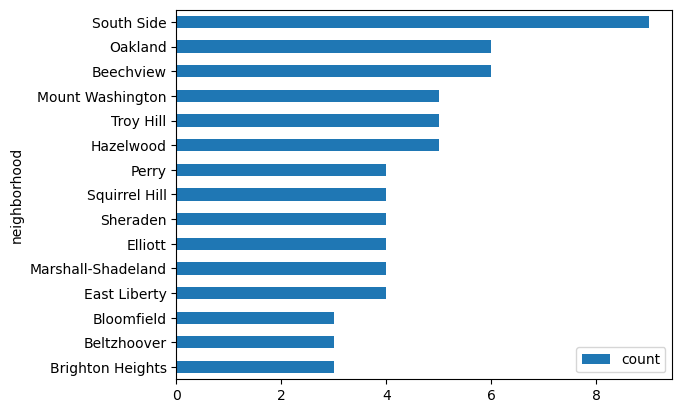

In [102]:
colors = ['red', 'blue', 'green']
(
    parksFinal
        .reset_index()
        .drop_duplicates(subset = 'neighborhood')
        .set_index('neighborhood')
        .drop(columns = ['name', 'type'])
        .head(15)
        .sort_values(by = 'count')
        .plot.barh()
)

## **Conclusion**

Using a dataset containing the neighborhood parks in Pittsburgh, I concluded that South Side is the best neighborhood based on the sheer number of parks. To come to this conclusion I removed unneccesary columns, removed irrelevant "types", combined neighborhoods based on cardinal directions, and counted the number of parks within each neighborhood. South side had the most at 9, followed by Beechview and Oakland at 6, and Hazelwood, Mount Washington, and Troy Hill at 5.

I was pretty suprised that South Side came out on top because I expected it to be much lower. I would have guessed Squirrel Hill as the number one spot because it includes two of the largest parks in Pittsburgh, Frick and Schenley. The reason it did not appear in the top 5 is due to the datasets lack of any acreage metric. Incorporating an acreage metric would drastically change the results, most likely making my favorite neighborhood, Squirrel Hill, number one.